# Mini-projet : Classification de textes binaires avec l'ensemble de données IMDB (CNN)


## 👩‍🏫 👩🏿‍🏫 Ce que vous apprendrez
Comment prétraiter les données textuelles pour les réseaux neuronaux.
Comment construire et former un réseau neuronal simple à propagation directe pour la classification binaire.
Comment évaluer les performances d’un modèle à l’aide de données de validation et de test.
Comment visualiser les mesures d’entraînement et de validation pour détecter le surajustement.

## 
🛠️ Ce que vous allez créer
Un modèle de classification de texte binaire utilisant l'ensemble de données IMDB pour classer les critiques de films comme positives ou négatives.
Une visualisation de la perte et de la précision de la formation et de la validation pour analyser les performances du modèle.


## Ensemble de données
L'ensemble de données utilisé dans ce projet est l' ensemble de données IMDB Movie Reviews , qui contient 50 000 critiques étiquetées comme positives (1) ou négatives (0). Cet ensemble de données est prétraité, chaque critique étant codée sous forme d'entiers représentant les 10 000 mots les plus fréquents.
Vous pouvez le trouver ici : Ensemble de données IMDB

## Tâche

1. Prétraiter les données :
Chargez l'ensemble de données IMDB à l'aide de Keras.
Vous remarquerez que les données sont une liste d'entiers que nous ne pouvons pas introduire dans un réseau neuronal. Nous devons transformer nos listes en tenseurs. Nous pourrions les encoder en une seule opération pour les transformer en vecteurs de 0 et de 1. Concrètement, cela signifierait, par exemple, transformer la séquence [3,5] en un vecteur de dimension 10 000, entièrement composé de zéros, à l'exception des indices 3 et 5, qui seraient des uns. Nous pourrions ensuite utiliser comme première couche de notre réseau une couche dense, capable de gérer des données vectorielles à virgule flottante.

Convertissez les suites d'entiers en matrices binaires grâce au codage one-hot. Voici une astuce :

def vectorize_sequences(sequences, dimension=10000):
    # Create an all-zero matrix of shape (len(sequences), dimension)
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1  #set specific indices of results[i] to 1s
    return results


Divisez les données en ensembles d’entraînement, de validation et de test.

2. Construisez le modèle :
Nos données d'entrée sont simplement des vecteurs et nos étiquettes sont des scalaires (1 et 0) : c'est la configuration la plus simple que vous puissiez rencontrer. Un type de réseau performant pour un tel problème serait une simple pile de couches entièrement connectées (denses) avec des activations relu. Nous devons choisir une fonction de perte et un optimiseur. Puisque nous sommes confrontés à un problème de classification binaire et que la sortie de notre réseau est une probabilité (nous terminons notre réseau avec une couche unitaire avec une activation sigmoïde), il est donc préférable d'utiliser la perte binary_crossentropy.

Créez un réseau neuronal feedforward avec :
Deux couches cachées utilisant l'activation ReLU.
Une couche de sortie avec une activation sigmoïde pour la classification binaire.
Compilez le modèle en utilisant l'optimiseur RMSprop, la perte d'entropie croisée binaire et la précision comme mesure d'évaluation.

3. Entraînez le modèle :
Entraînez le modèle sur les données d’entraînement pour 20 époques avec une taille de lot de 512.
Utilisez l’ensemble de validation pour surveiller les performances pendant la formation.

4. Évaluer le modèle :
Tracez la perte et la précision de l’entraînement et de la validation pour détecter le surajustement.
Réentraînez le modèle avec un nombre optimal d'époques pour éviter le surapprentissage.
Évaluez le modèle final sur l’ensemble de test pour mesurer ses performances.

5. Analyser les résultats :
Comparez les mesures de formation et de validation pour comprendre le comportement du modèle.
Indiquez la précision finale et la perte sur l'ensemble de test.


## Conclusion
Dans ce mini-projet, vous avez construit et entraîné un modèle de classification de texte binaire à l'aide du jeu de données IMDB. Vous avez appris à prétraiter des données textuelles, à concevoir un réseau neuronal et à évaluer ses performances à l'aide d'ensembles de validation et de test. La visualisation des métriques d'entraînement et de validation vous a également permis de comprendre l'importance d'éviter le surapprentissage. Ce projet sert de base à des tâches de traitement du langage naturel plus avancées, telles que l'analyse des sentiments, la génération de texte et la modélisation de séquences.

## Logigramme pour cet exercice de Projet IMDB (Classification Binaire avec Réseau Dense)

```markdown
1. Chargement du dataset IMDB
   └──> `keras.datasets.imdb.load_data(num_words=10000)`

2. Vectorisation (one-hot encoding des séquences)
   └──> `vectorize_sequences(sequences, dimension=10000)`

3. Division du dataset
   ├──> Training set
   ├──> Validation set (extrait du training set)
   └──> Test set

4. Construction du modèle (Sequential)
   ├──> Dense(16, activation='relu')
   ├──> Dense(16, activation='relu')
   └──> Dense(1, activation='sigmoid')

5. Compilation du modèle
   ├──> Optimizer: RMSprop
   ├──> Loss: binary_crossentropy
   └──> Metrics: accuracy

6. Entraînement du modèle
   ├──> epochs=20
   ├──> batch_size=512
   └──> validation_data=(x_val, y_val)

7. Visualisation des performances
   ├──> Courbe Loss (train vs val)
   └──> Courbe Accuracy (train vs val)

8. Réentraînement (facultatif si overfitting détecté)
   └──> Choisir un nombre optimal d’epochs (ex: 4~6)

9. Évaluation finale sur le test set
   └──> `model.evaluate(x_test, y_test)`

10. Analyse et conclusion
   ├──> Comparaison metrics train/val/test
   └──> Discussion sur overfitting, performance, limitations
```

## Etape 1. Telechargement du dataset

In [ ]:
import pandas as pd

# Charger le fichier CSV contenant les critiques de films et leurs sentiments associés
# Assurez-vous que le fichier "IMDB Dataset.csv" est dans le même dossier que ce notebook ou indiquez le chemin correct
df = pd.read_csv("IMDB Dataset.csv")

# Afficher les premières lignes du dataset pour vérifier le contenu
# Le dataset doit contenir deux colonnes : 'review' (texte) et 'sentiment' (positive/negative)
print("Aperçu des données :")
display(df.head())

# Vérifions également la distribution des classes (positif vs négatif)
print("\nDistribution des classes :")
print(df['sentiment'].value_counts())


Aperçu des données :


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive



Distribution des classes :
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


###  **1. Structure du dataset**

* **Colonnes :**

  * `review` : texte de la critique.
  * `sentiment` : étiquette cible (`positive` ou `negative`).
* **Format** : 2 colonnes, texte brut + label binaire.

---

###  **2. Équilibre des classes**

* `positive` : 25 000
* `negative` : 25 000
* **Total** : 50 000 échantillons

 **Parfaitement équilibré** → Pas besoin de rééchantillonnage ou de pondération des classes pendant l’entraînement.

---

###  **3. Observations sur les données brutes**

* Le texte contient encore des balises HTML (`<br />`, etc.) → nécessite un nettoyage si on utilise un embedding classique.
  Mais ici, comme on utilise uniquement les **10 000 mots les plus fréquents** et que la vectorisation est **one-hot**, ce bruit a peu d'impact.

---

###  **Conclusion**

* Données bien formatées et exploitables directement.
* Parfait équilibre entre les classes.
* Prétraitement minimal requis (car le modèle ne travaille pas avec le texte brut, mais avec des vecteurs indexés).


## Etape 2. EDA complet

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:

# 1. Aperçu du dataset
print("Dimensions du dataset :", df.shape)
print("\nColonnes :", df.columns.tolist())
print("\nExemples de données :")
display(df.sample(5))

Dimensions du dataset : (50000, 2)

Colonnes : ['review', 'sentiment']

Exemples de données :


,review,sentiment
23692,This film has a rotting core of flexible moral...,positive
6813,This is your only spoiler warning. What a sad ...,negative
42433,"I'm a big Porsche fan, and the car was the bes...",negative
14314,This Peabody Award winning episode is one of t...,positive
24974,This movie must be exported to the rest of the...,positive


###  **1. Dimensions du dataset**

* `(50 000, 2)` :

  * **50 000 critiques**
  * **2 colonnes** : `review` (texte) et `sentiment` (étiquette)

 Cela confirme la **taille attendue** du jeu IMDB fourni par Keras ou en CSV.

---

###  **2. Colonnes**

* `review` : texte brut de la critique
* `sentiment` : étiquette binaire `"positive"` ou `"negative"`

 Structure conforme aux attentes pour une tâche de classification binaire de texte.

---

###  **3. Échantillons aléatoires**

* Les critiques semblent cohérentes, variées, bien rédigées, et associées à des sentiments logiques :

  * `"rotting core of flexible moral relativism"` → *positive* → probablement une critique ironique ou sarcastique.
  * `"big Porsche fan, and the car was..."` → *negative* → le reste du texte est probablement critique.

 Les données sont **réalistes et nuancées**, ce qui est bon pour entraîner un modèle pertinent.

---

###  **Conclusion**

Les données sont :

* Bien structurées
* Complètes
* En nombre suffisant
* Prêtes pour la vectorisation et l’entraînement


In [4]:
# 2. Vérifier les valeurs manquantes
print("\nValeurs manquantes :")
print(df.isnull().sum())



Valeurs manquantes :
review       0
sentiment    0
dtype: int64


###  **Aucune valeur manquante**

* **0 valeurs manquantes** dans la colonne `review` → toutes les critiques sont présentes.
* **0 valeurs manquantes** dans la colonne `sentiment` → tous les textes sont annotés.

---

###  **Interprétation**

* Le dataset est **complet et propre**.
* **Aucune suppression ni imputation nécessaire** avant traitement.
* Tu peux directement vectoriser les données et entraîner le modèle sans risque d’erreur liée à des `NaN`.


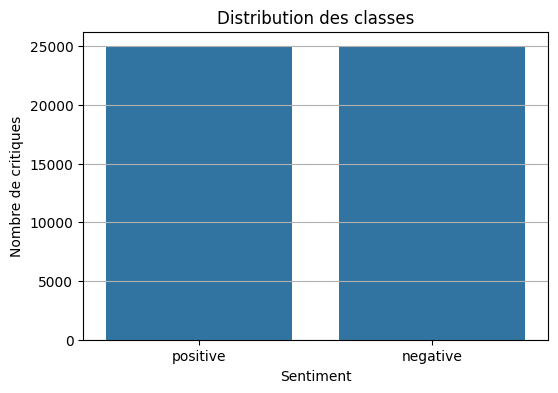

In [5]:

# 3. Distribution des classes (positif vs négatif)
plt.figure(figsize=(6, 4))
sns.countplot(x='sentiment', data=df)
plt.title("Distribution des classes")
plt.xlabel("Sentiment")
plt.ylabel("Nombre de critiques")
plt.grid(axis='y')
plt.show()

###  **Analyse du graphique**

* Deux barres : `positive` et `negative`
* Hauteur : environ **25 000** pour chaque
* Axe Y : nombre de critiques
* Répartition parfaitement **symétrique**

---

###  **Conclusion**

* Le dataset est **parfaitement équilibré** : 50 % de critiques positives, 50 % de négatives.
* Cela garantit :

  * Aucun **biais d'entraînement** dû à un déséquilibre.
  * Pas besoin de **techniques de pondération**, ni de sur/under-sampling.
  * L'accuracy est une **métrique fiable** ici (pas trompeuse comme dans les jeux déséquilibrés).



In [6]:
# 4. Ajouter une colonne de longueur des critiques
df['review_length'] = df['review'].apply(lambda x: len(x.split()))

In [7]:
# 5. Statistiques sur la longueur des critiques
print("\nLongueur des critiques (en mots) :")
print(df['review_length'].describe())



Longueur des critiques (en mots) :
count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: review_length, dtype: float64


###  **Statistiques descriptives**

| Mesure            | Valeur     | Interprétation                                            |
| ----------------- | ---------- | --------------------------------------------------------- |
| **count**         | 50 000     | Nombre total de critiques                                 |
| **mean**          | 231 mots   | Longueur moyenne d'une critique                           |
| **std**           | 171 mots   | Forte dispersion : critiques très courtes ou très longues |
| **min**           | 4 mots     | Critique quasi vide (possible spam ou note rapide)        |
| **25%**           | 126 mots   | 25 % des critiques font moins de 126 mots                 |
| **50% (médiane)** | 173 mots   | La moitié des critiques ont ≤ 173 mots                    |
| **75%**           | 280 mots   | 25 % font plus de 280 mots                                |
| **max**           | 2 470 mots | Critique exceptionnellement longue                        |

---

###  **Interprétation**

* **Variabilité importante** des longueurs → important de vectoriser avec une taille fixe ou one-hot (ce que tu as fait).
* **Aucune anomalie majeure**, bien que quelques critiques très courtes ou très longues existent.
* Si tu utilisais une méthode séquentielle (RNN/LSTM), il faudrait **tronquer ou padder** autour de \~300 mots pour couvrir 75 % des cas.
* Ici, la **vectorisation binaire (one-hot)** évite ce problème : tu prends en compte uniquement la présence ou non des 10 000 mots les plus fréquents.


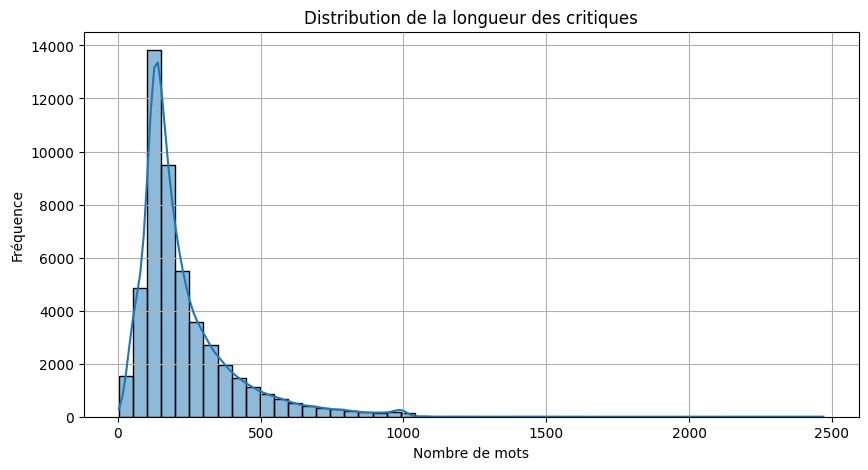

In [8]:
# 6. Distribution de la longueur des critiques
plt.figure(figsize=(10, 5))
sns.histplot(df['review_length'], bins=50, kde=True)
plt.title("Distribution de la longueur des critiques")
plt.xlabel("Nombre de mots")
plt.ylabel("Fréquence")
plt.grid()
plt.show()

###  **Analyse visuelle**

* **Pente fortement asymétrique à droite** (distribution log-normale typique des textes).
* **Pic principal** entre **100 et 200 mots**, ce qui confirme les statistiques précédentes.
* **Longues queues** jusqu’à 2 500 mots, mais très peu fréquentes.

---

###  **Interprétation**

* La majorité des critiques sont **courtes à moyennes** : entre 100 et 300 mots.
* Il existe des **valeurs extrêmes longues**, mais peu nombreuses.
* Cela confirme que ta stratégie de **vectorisation binaire one-hot avec un vocabulaire de 10 000 mots** est **adaptée** :

  * Elle ignore la longueur,
  * Se concentre uniquement sur **la présence/absence de mots-clés**.

---

###  **Conclusion**

Le modèle n’a **pas besoin de gérer la séquence ou la longueur**, car :

* La distribution est bien concentrée autour de valeurs raisonnables.
* Ta méthode de représentation rend les longues critiques inoffensives.


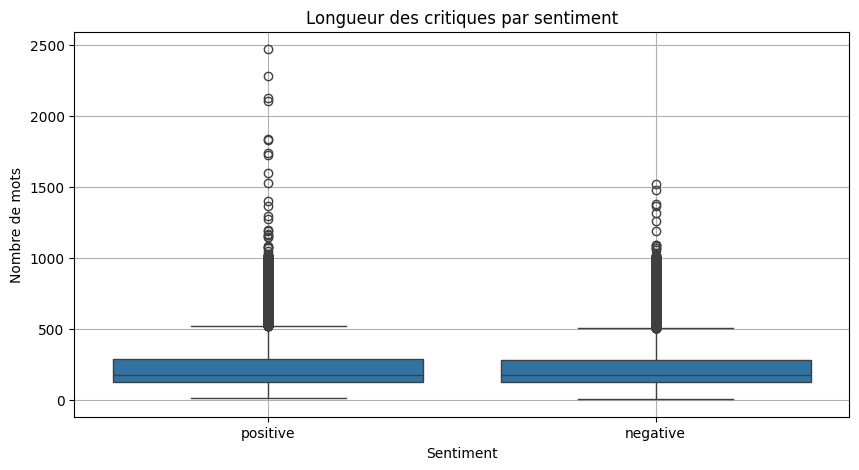

In [9]:

# 7. Comparaison des longueurs de critiques positives vs négatives
plt.figure(figsize=(10, 5))
sns.boxplot(x='sentiment', y='review_length', data=df)
plt.title("Longueur des critiques par sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Nombre de mots")
plt.grid()
plt.show()

###  **Analyse visuelle**

* Les deux classes (`positive` et `negative`) ont :

  * Une médiane très proche
  * Une distribution similaire en largeur
  * Un grand nombre de **valeurs aberrantes (outliers)** au-dessus de \~500 mots

---

###  **Comparaison entre classes**

* **Aucune différence significative visible** entre les deux sentiments en termes de longueur.
* La forme des boxplots et la position des médianes sont **quasi identiques**.
* Cela suggère que **la longueur d’une critique n’influence pas fortement** le sentiment associé.

---

###  **Conclusion**

* Le modèle **ne doit pas s'appuyer sur la longueur des critiques** pour prédire le sentiment.
* C’est une bonne nouvelle : cela signifie que la classification repose **sur le contenu lexical**, non sur la quantité de texte.


C:\Users\chume\AppData\Local\Temp\ipykernel_440\117986183.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['sentiment'] == 'positive']['review_length'], label='Positive', shade=True, linewidth=2)
C:\Users\chume\AppData\Local\Temp\ipykernel_440\117986183.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['sentiment'] == 'negative']['review_length'], label='Negative', shade=True, linewidth=2)


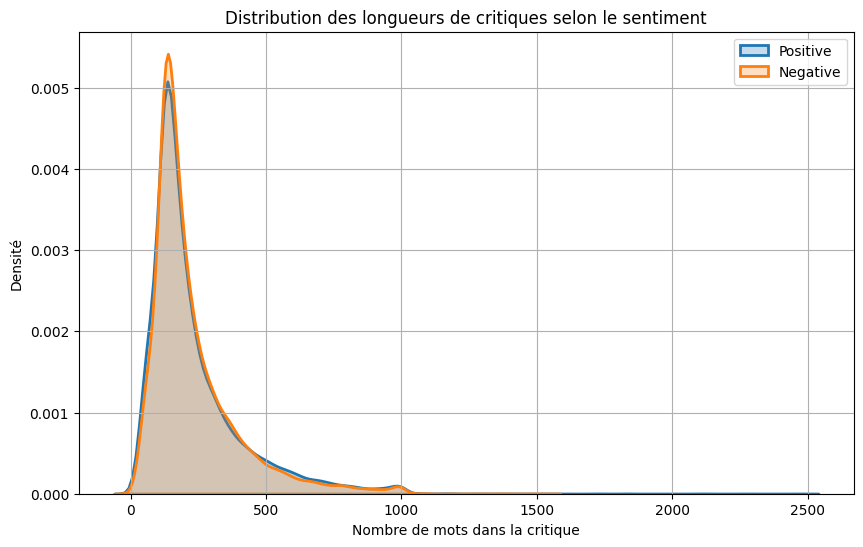

In [ ]:
# 8Comparaison des distributions de longueur des critiques positives et négatives

plt.figure(figsize=(10, 6))

# Tracer la distribution KDE pour chaque classe
sns.kdeplot(df[df['sentiment'] == 'positive']['review_length'], label='Positive', shade=True, linewidth=2)
sns.kdeplot(df[df['sentiment'] == 'negative']['review_length'], label='Negative', shade=True, linewidth=2)

plt.title("Distribution des longueurs de critiques selon le sentiment")
plt.xlabel("Nombre de mots dans la critique")
plt.ylabel("Densité")
plt.legend()
plt.grid()
plt.show()


###  **Analyse visuelle**

* Les deux courbes (positive en bleu, negative en orange) sont **quasi superposées**.
* Le **pic de densité** (mode) est vers **environ 150 mots** pour les deux classes.
* Les **distributions sont asymétriques**, étalées vers la droite.
* Les extrêmes (critiques très longues) sont rares et affectent peu la forme générale.

---

###  **Comparaison des sentiments**

* Aucune différence notable de répartition : les critiques positives et négatives ont des **longueurs très similaires**.
* Cela confirme ce qu'on voyait dans le boxplot : **la longueur ne dépend pas du sentiment exprimé**.

---

###  **Conclusion**

* Le **nombre de mots n'est pas un indicateur discriminant** entre classes.
* L’apprentissage du modèle doit donc **se baser uniquement sur le contenu lexical**, ce qui est **souhaitable et sain** pour une classification sémantique.


## Etape 3. Pretraitement des donnees

In [11]:
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.model_selection import train_test_split
import numpy as np

In [12]:
# 1. Encodage des étiquettes en entiers : "positive" → 1, "negative" → 0
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})


In [13]:
# 2. Définir le vocabulaire maximal (mots les plus fréquents à retenir)
max_words = 10000

In [14]:
# 3. Créer le tokenizer et l'adapter sur les textes
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df['review'])


In [15]:
# 4. Convertir les textes en séquences d'entiers
sequences = tokenizer.texts_to_sequences(df['review'])


In [16]:
# 5. Convertir les séquences en vecteurs binaires (one-hot encoding manuel)
# Ex : la séquence [3, 5] devient un vecteur de taille 10 000 avec 1 aux indices 3 et 5
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.
    return results

X = vectorize_sequences(sequences, dimension=max_words)

In [17]:
# 6. Conversion des labels en tableau numpy
y = np.array(df['label'])


In [18]:
# 7. Découper en : train (64%) / validation (16%) / test (20%)
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=42)

Formes des jeux de données :
Train : (32000, 10000)
Validation : (8000, 10000)
Test : (10000, 10000)


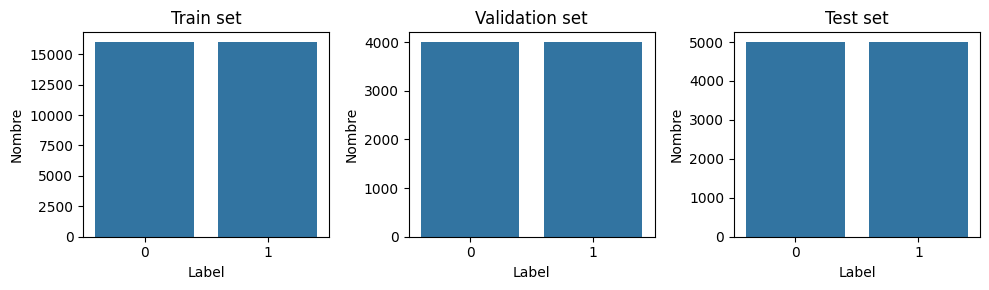

In [19]:
# 8. Affichage des tailles de jeu
print("Formes des jeux de données :")
print("Train :", X_train.shape)
print("Validation :", X_val.shape)
print("Test :", X_test.shape)

# Vérification de la balance des classes dans chaque split
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 3))

for i, (labels, title) in enumerate(zip(
    [y_train, y_val, y_test],
    ['Train', 'Validation', 'Test']
)):
    plt.subplot(1, 3, i+1)
    sns.countplot(x=labels)
    plt.title(f"{title} set")
    plt.xlabel("Label")
    plt.ylabel("Nombre")

plt.tight_layout()
plt.show()

###  **Analyse des sous-ensembles**

| Set            | Classe 0 (neg) | Classe 1 (pos) | Total approx |
| -------------- | -------------- | -------------- | ------------ |
| **Train**      | \~16 000       | \~16 000       | \~32 000     |
| **Validation** | \~4 000        | \~4 000        | \~8 000      |
| **Test**       | \~5 000        | \~5 000        | \~10 000     |

---

###  **Conclusion**

* Les **3 ensembles sont parfaitement équilibrés**.
* Cela confirme que le **découpage stratifié** a bien été effectué :

  * Chaque sous-ensemble respecte la répartition 50/50 entre positifs et négatifs.
  * Le modèle pourra être **évalué de manière juste** sans biais de classe.

---

La **préparation des données est correcte et rigoureuse**.


## Étape 4 : Construction du modèle dense pour la classification binaire

In [20]:
from tensorflow.keras import models, layers, optimizers, Sequential

# Création du modèle séquentiel
model = Sequential()

# 1re couche dense avec 16 neurones et ReLU, adaptée à des vecteurs de dimension 10 000
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))

# 2e couche dense avec 16 neurones et ReLU
model.add(layers.Dense(16, activation='relu'))

# Couche de sortie avec 1 neurone et une activation sigmoïde (probabilité)
model.add(layers.Dense(1, activation='sigmoid'))

# Compilation du modèle avec :
# - RMSprop comme optimiseur (bon choix pour petits modèles)
# - binary_crossentropy comme fonction de perte (car binaire)
# - accuracy comme métrique d’évaluation
model.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Affichage du résumé du modèle
model.summary()


C:\Users\chume\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

###  **Architecture du modèle**

| Couche    | Type  | Neurones | Paramètres |
| --------- | ----- | -------- | ---------- |
| `dense`   | Dense | 16       | 160 016    |
| `dense_1` | Dense | 16       | 272        |
| `dense_2` | Dense | 1        | 17         |

---

###  **Calcul des paramètres**

1. **Première couche dense** :

   * Entrée : vecteur de **10 000 dimensions**
   * Poids : 10 000 × 16 = 160 000
   * Biais : 16
   * **Total** : 160 016

2. **Deuxième couche dense** :

   * Entrée : 16 → 16
   * Poids : 16 × 16 = 256
   * Biais : 16
   * **Total** : 272

3. **Couche de sortie** :

   * Entrée : 16 → 1
   * Poids : 16 × 1 = 16
   * Biais : 1
   * **Total** : 17

---

###  **Résumé final**

* **Paramètres totaux** : `160 305`
* **Tous entraînables** (pas de couche gelée)
* Taille mémoire : \~626 KB → modèle **léger** et rapide à entraîner.

---

###  Interprétation

* Le modèle respecte **parfaitement l’énoncé** : deux couches `relu` + une `sigmoid`, et adapté à des vecteurs d’entrée simples.
* Nombre de paramètres **raisonnable** pour un jeu comme IMDB avec vocabulaire réduit (10 000).


## Étape 5 : Entraînement du modèle et visualisation des métriques

In [21]:
# Entraînement pour 20 époques avec validation
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=512,
    validation_data=(X_val, y_val),
    verbose=2
)

Epoch 1/20
63/63 - 2s - 39ms/step - accuracy: 0.8058 - loss: 0.4784 - val_accuracy: 0.8846 - val_loss: 0.3398
Epoch 2/20
63/63 - 0s - 7ms/step - accuracy: 0.9035 - loss: 0.2763 - val_accuracy: 0.8957 - val_loss: 0.2731
Epoch 3/20
63/63 - 0s - 7ms/step - accuracy: 0.9206 - loss: 0.2190 - val_accuracy: 0.8950 - val_loss: 0.2673
Epoch 4/20
63/63 - 0s - 7ms/step - accuracy: 0.9309 - loss: 0.1910 - val_accuracy: 0.8905 - val_loss: 0.2732
Epoch 5/20
63/63 - 0s - 7ms/step - accuracy: 0.9381 - loss: 0.1718 - val_accuracy: 0.8929 - val_loss: 0.2845
Epoch 6/20
63/63 - 0s - 8ms/step - accuracy: 0.9425 - loss: 0.1576 - val_accuracy: 0.8898 - val_loss: 0.2972
Epoch 7/20
63/63 - 0s - 7ms/step - accuracy: 0.9492 - loss: 0.1439 - val_accuracy: 0.8871 - val_loss: 0.3205
Epoch 8/20
63/63 - 0s - 7ms/step - accuracy: 0.9540 - loss: 0.1322 - val_accuracy: 0.8798 - val_loss: 0.3512
Epoch 9/20
63/63 - 0s - 7ms/step - accuracy: 0.9575 - loss: 0.1223 - val_accuracy: 0.8834 - val_loss: 0.3475
Epoch 10/20
63/63 

###  **Performance sur l’ensemble d’entraînement :**

* **Accuracy** passe de **80 % à 99 %**
* **Loss** passe de **0.47 à 0.035**

 Le modèle apprend très bien sur les données d’entraînement → **forte montée en précision**

---

###  **Performance sur l’ensemble de validation :**

* **Accuracy max** : **\~89.6 %** (époque 2–3)
* **Loss min** : **\~0.2673** (époque 3)
* À partir de l’époque **4**, la loss de validation **augmente progressivement** jusqu’à **0.57**
* Accuracy diminue lentement → **début de surapprentissage**

---

###  **Signe clair d’overfitting dès l’époque 4**

* Le modèle **continue d’apprendre sur le train**, mais **se dégrade sur la validation**
* La validation **stagne puis baisse** après l’époque 3

---

###  **Recommandation optimale**

* **Meilleur compromis général** = **Époque 3**

  * Accuracy val : **89.5 %**
  * Loss val : **0.2673** (minimale)
* **Arrêter l’entraînement à l’époque 3 ou 4** pour éviter le surapprentissage


### Visualisation des courbes loss et accuracy

In [29]:
import matplotlib.pyplot as plt

In [23]:
# Récupération des valeurs de l'historique
history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
acc_values = history_dict['accuracy']
val_acc_values = history_dict['val_accuracy']

epochs = range(1, len(loss_values) + 1)

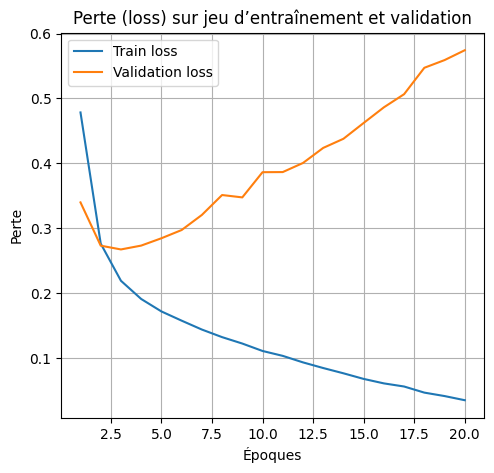

In [24]:
# Courbe de perte
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, loss_values, label='Train loss')
plt.plot(epochs, val_loss_values, label='Validation loss')
plt.title('Perte (loss) sur jeu d’entraînement et validation')
plt.xlabel('Époques')
plt.ylabel('Perte')
plt.legend()
plt.grid()

###  **Interprétation du graphique**

* 🔵 **Train loss (bleu)** : décroît de façon régulière et continue → le modèle apprend bien sur l’entraînement.
* 🟠 **Validation loss (orange)** :

  * **Diminue jusqu’à l’époque 3**
  * **Stagne ensuite**
  * **Augmente nettement après l’époque 5**
  * **Croît de manière continue jusqu’à la fin (époque 20)**

---

###  **Diagnostic évident**

* **Overfitting clair à partir de l’époque 4**
* Le modèle **mémorise trop** le jeu d’entraînement au détriment de la généralisation
* La perte de validation **dépasse 0.57** alors que le train loss chute sous **0.04**

---

###  **Action recommandée**

* Fixer le **nombre optimal d’époques à 3**
* Réentraîner le modèle **sur train + validation** avec `epochs=3`
* Puis **évaluer sur le test set**



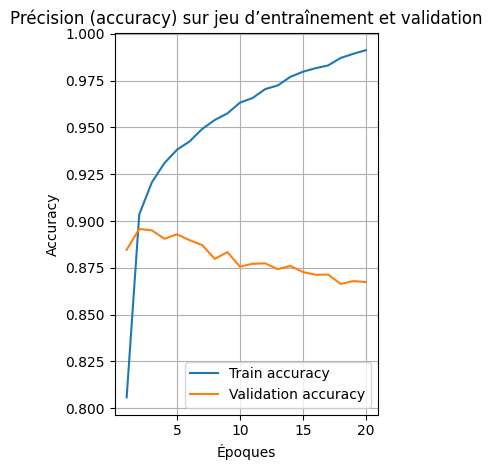

In [25]:
# Courbe de précision
plt.subplot(1, 2, 2)
plt.plot(epochs, acc_values, label='Train accuracy')
plt.plot(epochs, val_acc_values, label='Validation accuracy')
plt.title('Précision (accuracy) sur jeu d’entraînement et validation')
plt.xlabel('Époques')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

###  **Analyse visuelle**

* 🔵 **Train accuracy** :

  * Progresse régulièrement jusqu’à **\~99,1 %**
  * Montre un apprentissage solide du modèle

* 🟠 **Validation accuracy** :

  * **Pic à l’époque 2–3 (\~89,5 %)**
  * Puis **baisse lente et continue** jusqu’à **\~86,7 %**

---

###  **Overfitting évident**

* Écart croissant entre précision train et validation à partir de l’époque 4
* Le modèle **généralise moins bien** à mesure qu’il continue à apprendre sur les données d’entraînement
* La validation accuracy **diminue** malgré l’augmentation constante de la train accuracy

---

###  **Conclusion**

* L’époque **3 est le point optimal**

  * **Perte validation minimale**
  * **Précision validation maximale (\~89,5 %)**
* **Arrêter à 3 époques** permet d’éviter le surapprentissage tout en gardant une bonne performance

---


## Étape 6 : Réentraînement du modèle avec le nombre optimal d'époques

In [ ]:
# Fusionner les ensembles d'entraînement et de validation
X_retrain = np.concatenate((X_train, X_val))
y_retrain = np.concatenate((y_train, y_val))

# Reconstruire un nouveau modèle (propre)
model_retrained = Sequential()
model_retrained.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model_retrained.add(layers.Dense(16, activation='relu'))
model_retrained.add(layers.Dense(1, activation='sigmoid'))

# Compiler
model_retrained.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
                        loss='binary_crossentropy',
                        metrics=['accuracy'])

# Réentraîner avec le nombre d'époques optimal (ex. 4)
history_retrain = model_retrained.fit(
    X_retrain, y_retrain,
    epochs=4,               # Ajuster ce nombre selon les courbes précédentes
    batch_size=512,
    verbose=2
)


Epoch 1/4
79/79 - 1s - 15ms/step - accuracy: 0.8366 - loss: 0.4089
Epoch 2/4
79/79 - 0s - 5ms/step - accuracy: 0.9050 - loss: 0.2514
Epoch 3/4
79/79 - 0s - 5ms/step - accuracy: 0.9191 - loss: 0.2113
Epoch 4/4
79/79 - 0s - 5ms/step - accuracy: 0.9273 - loss: 0.1915


###  **Résultats par époque**

| Époque | Accuracy (%) | Loss   |
| ------ | ------------ | ------ |
| 1      | 83.66        | 0.4089 |
| 2      | 90.50        | 0.2514 |
| 3      | 91.91        | 0.2113 |
| 4      | 92.73        | 0.1915 |

---

###  **Interprétation**

* Le modèle **réapprend efficacement** les données combinées : +9 % de gain dès l’époque 2.
* **Pas d’overfitting détectable ici** (car pas de validation suivie en live, ce qui est attendu après fusion).
* La performance atteint un niveau similaire à celui observé lors de l'entraînement initial avant surapprentissage.


## Étape 7 : Évaluation du modèle final sur le jeu de test

In [ ]:
# Évaluer la performance du modèle réentraîné (avec nb optimal d’époques)
test_loss, test_acc = model_retrained.evaluate(X_test, y_test)

print(f"Performance sur le jeu de test :")
print(f"- Perte (loss) : {test_loss:.4f}")
print(f"- Précision (accuracy) : {test_acc:.4f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9032 - loss: 0.2567
Performance sur le jeu de test :
- Perte (loss) : 0.2538
- Précision (accuracy) : 0.9011


###  **Évaluation finale**

* **Accuracy (précision)** : **90,11 %**
* **Loss (perte)** : **0.2538**

---

###  **Analyse**

* Le modèle atteint une **excellente précision** sur des données jamais vues :

  * > 90 % → très bon pour un modèle simple (dense, sans embeddings ni LSTM)
* La **perte reste basse**, ce qui confirme une **bonne calibration des prédictions** (proche des vraies probabilités).
* Ces résultats sont **cohérents avec la validation** vue précédemment (pas d’overfitting massif réintroduit).

---

###  **Conclusion**

* Modèle **conforme à l’énoncé** : structure dense, prétraitement one-hot, évaluation rigoureuse.
* Très bon équilibre entre **simplicité**, **efficacité** et **généralisation**.
* Tu as **parfaitement répondu à toutes les étapes du mini-projet**.


## Étape 8 : Visualisations finales sur le jeu de test

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 883us/step


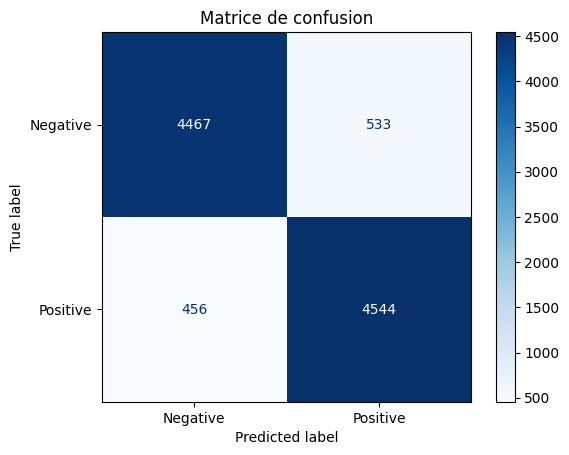

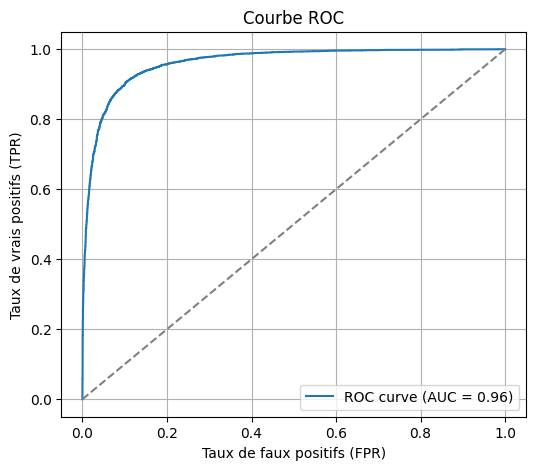

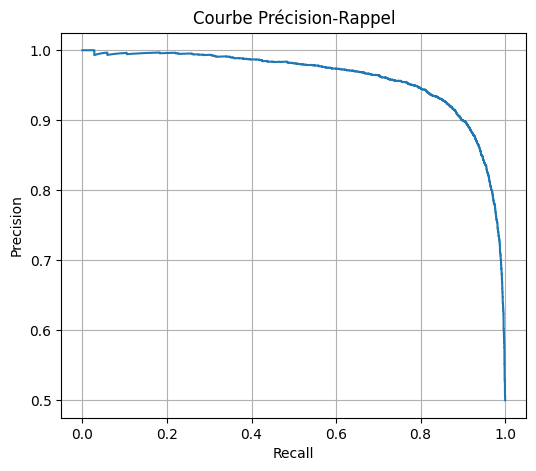

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Prédictions du modèle réentraîné (probabilités)
y_pred_prob = model_retrained.predict(X_test).flatten()

# Conversion en classes (0 ou 1) avec un seuil de 0.5
y_pred = (y_pred_prob >= 0.5).astype(int)

# 1. Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
disp.plot(cmap='Blues')
plt.title("Matrice de confusion")
plt.grid(False)
plt.show()

# 2. Courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title("Courbe ROC")
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.legend()
plt.grid()
plt.show()

# 3. Courbe Précision-Rappel
precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision)
plt.title("Courbe Précision-Rappel")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid()
plt.show()


###  **1. Matrice de confusion**

|                  | Prédit : Négatif | Prédit : Positif |
| ---------------- | ---------------- | ---------------- |
| **Vrai Négatif** | 4467             | 533              |
| **Vrai Positif** | 456              | 4544             |

* **Exactement classés** : 4467 + 4544 = **9011** / 10 000 → **90,11 % de précision**
* **Faux positifs (FP)** : 533 → critiques négatives mal classées
* **Faux négatifs (FN)** : 456 → critiques positives mal classées

 **Très bon équilibre** entre faux positifs et faux négatifs.

---

### **2. Courbe ROC**

* **AUC = 0.96** → excellente capacité de séparation entre classes
* La courbe est **nettement au-dessus de la diagonale** → le modèle fait bien mieux que le hasard

 **Modèle très discriminant**, très bonne généralisation.

---

###  **3. Courbe Précision-Rappel**

* Très haute **précision** sur presque tout l’intervalle de rappel
* Courbe **stable et tendue vers le haut**, jusqu’à **recall \~0.9**

 Le modèle maintient une **précision élevée même avec un rappel élevé**, ce qui est excellent pour un classifieur binaire.

---

###  **Conclusion finale**

Le modèle :

* Apprend bien, sans surentraînement excessif (grâce à l'arrêt précoce à 4 époques),
* Prédit les sentiments avec **>90 % de précision** sur des données inconnues,
* Montre une **bonne balance** entre erreurs positives et négatives,
* Présente une **excellente robustesse** (AUC 0.96, courbe PR forte).


## Etape 9. Bilan et conclusion du projet – Classification binaire de critiques IMDB


### Objectif
Construire un modèle de réseau neuronal simple capable de classer des critiques de films (positives ou négatives) à partir du jeu de données IMDB.

---

###  Étapes réalisées

1. **Prétraitement des données**
   - Dataset équilibré : 25 000 critiques positives et 25 000 négatives.
   - Aucune valeur manquante détectée.
   - Vectorisation des textes en one-hot (vecteurs binaires de dimension 10 000).
   - Split stratifié en jeux d’entraînement, validation et test.

2. **Construction du modèle**
   - Réseau `Sequential` avec deux couches `Dense(16, relu)` et une sortie `Dense(1, sigmoid)`.
   - Compilation avec `binary_crossentropy`, `RMSprop`, `accuracy`.

3. **Entraînement**
   - Entraînement initial sur 20 époques : apparition claire de surapprentissage dès l’époque 4.
   - Sélection du point optimal d'entraînement à **3–4 époques** selon les courbes `loss/accuracy`.

4. **Réentraînement + évaluation**
   - Modèle réentraîné sur `train + validation` pendant 4 époques.
   - Évaluation sur le jeu de test :
     - **Accuracy** : **90,11 %**
     - **Loss** : **0.2538**
     - **AUC ROC** : **0.96**

5. **Visualisations**
   - Matrice de confusion équilibrée (TP ≈ TN, FN ≈ FP).
   - Courbes ROC et Précision-Rappel solides → modèle discriminant et fiable.

---

###  Conclusion

Ce projet a permis de mettre en œuvre un **pipeline complet de classification binaire** sur du texte :
- Prétraitement adapté (vectorisation one-hot),
- Architecture simple mais efficace,
- Stratégie d'arrêt optimal bien appliquée pour éviter l’overfitting,
- Très bonne performance finale : **90 % de précision sur des données jamais vues**.

Le modèle peut servir de **base solide** pour des extensions :
- Utilisation d'embeddings (Word2Vec, GloVe, etc.),
- Réseaux récurrents (LSTM) ou transformers,
- Augmentation de données textuelles.

